# Customer Segmentation Analysis
**Customer Churn Intelligence & Retention Analytics Platform**

The goal is to identify meaningful customer groups and determine which groups have higher churn risk, starting with interpretable business segmentation, followed by unsupervised machine learning (K-Means).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
import sys
import os

sys.path.append(os.path.abspath('..'))
from src.visualization import visualize

warnings.filterwarnings('ignore')
visualize.setup_style()

## Data Loading & Preprocessing

In [2]:
df = pd.read_csv('../data/processed/cleaned_telco_churn.csv')
if 'churn_value' in df.columns:
    df['churn'] = df['churn_value']

df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce')
df = df.dropna(subset=['total_charges']).copy()
print(f"Dataset shape: {df.shape}")

Dataset shape: (7043, 27)


## Part 1: Interpretable Business Segmentation
We define groups based on Tenure and Monthly Charges (excluding churn from the rules).
- **New & Budget**: Tenure <= 12, Charges <= median
- **New & Premium**: Tenure <= 12, Charges > median
- **Established & Budget**: Tenure > 12, Charges <= median
- **Established & Premium**: Tenure > 12, Charges > median

In [3]:
median_charges = df['monthly_charges'].median()

def assign_biz_segment(row):
    if row['tenure_months'] <= 12:
        return 'New & Premium' if row['monthly_charges'] > median_charges else 'New & Budget'
    else:
        return 'Established & Premium' if row['monthly_charges'] > median_charges else 'Established & Budget'

df['biz_segment'] = df.apply(assign_biz_segment, axis=1)

biz_summary = df.groupby('biz_segment').agg(
    Customers=('customerid', 'count'),
    Avg_Tenure=('tenure_months', 'mean'),
    Avg_Monthly_Charges=('monthly_charges', 'mean'),
    Churn_Rate=('churn', 'mean')
).reset_index()

biz_summary['% of Base'] = (biz_summary['Customers'] / len(df) * 100).round(1)
biz_summary = biz_summary.sort_values('Churn_Rate', ascending=False)
biz_summary

,biz_segment,Customers,Avg_Tenure,Avg_Monthly_Charges,Churn_Rate,% of Base
3,New & Premium,830,5.146988,83.776928,0.687952,11.8
2,New & Budget,1356,4.477139,39.155531,0.343658,19.3
1,Established & Premium,2685,47.121415,92.735158,0.248045,38.1
0,Established & Budget,2172,41.954880,38.900990,0.076427,30.8


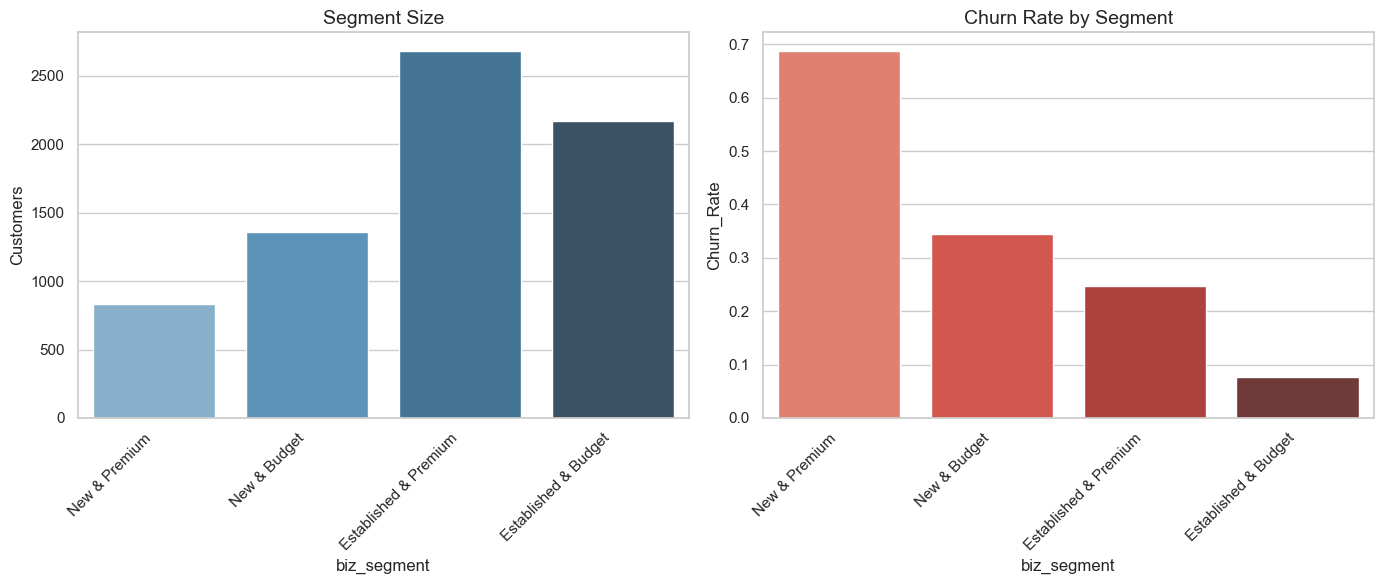

In [4]:
# Visualization of Business Segments
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=biz_summary, x='biz_segment', y='Customers', ax=ax1, palette='Blues_d')
ax1.set_title('Segment Size')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

sns.barplot(data=biz_summary, x='biz_segment', y='Churn_Rate', ax=ax2, palette='Reds_d')
ax2.set_title('Churn Rate by Segment')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Part 2: Unsupervised K-Means Clustering
Clustering based on numerical and encoded categorical engagement metrics (NOT churn).

In [5]:
# Feature Engineering for Clustering
features = ['tenure_months', 'monthly_charges']

# Encode binary features to use in clustering
df['is_month_to_month'] = (df['contract'] == 'Month-to-month').astype(int)
df['has_tech_support'] = (df['tech_support'] == 'Yes').astype(int)
df['has_online_security'] = (df['online_security'] == 'Yes').astype(int)

cluster_features = features + ['is_month_to_month', 'has_tech_support', 'has_online_security']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[cluster_features])

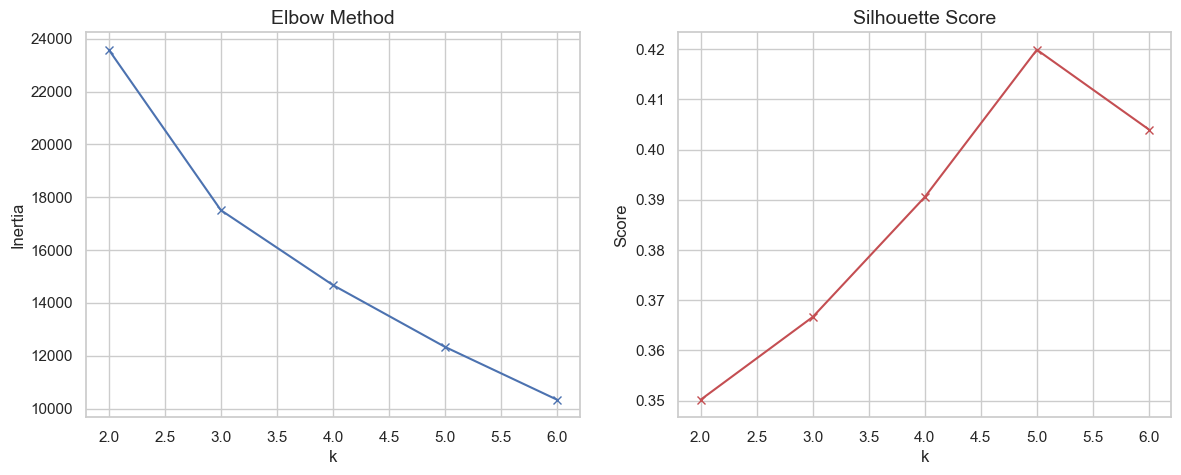

In [6]:
# Elbow Method & Silhouette Score
inertias = []
sil_scores = []
K = range(2, 7)

# We use a sample for silhouette score to speed it up
np.random.seed(42)
sample_idx = np.random.choice(range(len(X_scaled)), size=2000, replace=False)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled[sample_idx], kmeans.predict(X_scaled[sample_idx])))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(K, inertias, 'bx-')
ax1.set_title('Elbow Method')
ax1.set_xlabel('k')
ax1.set_ylabel('Inertia')

ax2.plot(K, sil_scores, 'rx-')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('k')
ax2.set_ylabel('Score')
plt.show()

Based on the Elbow curve and Silhouette score, **K=4** seems to offer a good balance of variance explained and cluster cohesion.

In [7]:
# Apply K-Means (K=4)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Map clusters to descriptive names based on their centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
cluster_df = pd.DataFrame(centroids, columns=cluster_features)
cluster_df['cluster'] = range(4)

# Create descriptive mapping
cluster_names = {
    0: 'Uncommitted Budget',
    1: 'Premium Loyalists',
    2: 'High-Flight-Risk (Premium, M2M)',
    3: 'Engaged Security/Support Users'
}
df['ml_segment'] = df['cluster'].map(cluster_names)

ml_summary = df.groupby('ml_segment').agg(
    Customers=('customerid', 'count'),
    Avg_Tenure=('tenure_months', 'mean'),
    Avg_Monthly_Charges=('monthly_charges', 'mean'),
    Pct_MonthToMonth=('is_month_to_month', 'mean'),
    Pct_TechSupport=('has_tech_support', 'mean'),
    Churn_Rate=('churn', 'mean')
).reset_index()

ml_summary['% of Base'] = (ml_summary['Customers'] / len(df) * 100).round(1)
ml_summary = ml_summary.sort_values('Churn_Rate', ascending=False)
ml_summary

,ml_segment,Customers,Avg_Tenure,Avg_Monthly_Charges,Pct_MonthToMonth,Pct_TechSupport,Churn_Rate,% of Base
1,"High-Flight-Risk (Premium, M2M)",3083,15.353876,64.091486,0.998378,0.127149,0.461888,43.8
3,Uncommitted Budget,1085,34.658065,75.131244,0.626728,0.152074,0.220276,15.4
2,Premium Loyalists,1473,55.419552,84.275221,0.077393,1.000000,0.085540,20.9
0,Engaged Security/Support Users,1402,43.806705,37.708809,0.002140,0.009986,0.057061,19.9


## Visualizing ML Segments

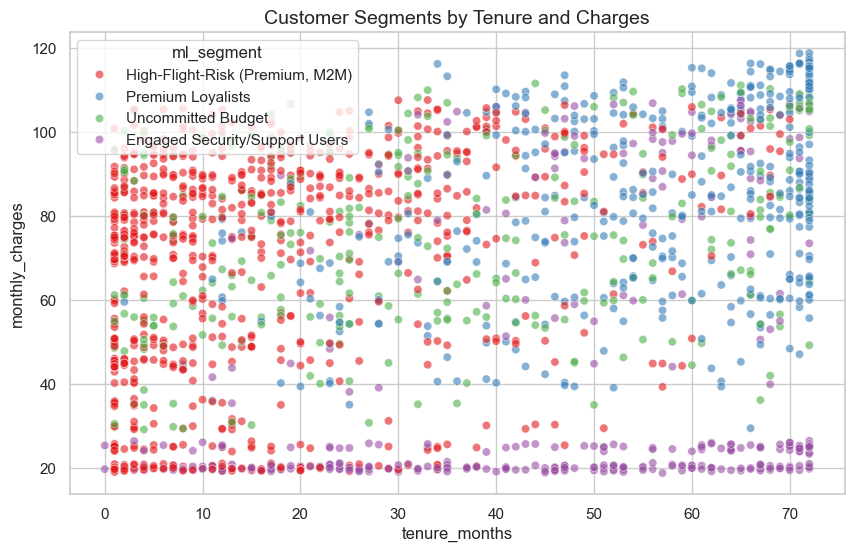

In [8]:
# Segment Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(2000, random_state=42), x='tenure_months', y='monthly_charges', hue='ml_segment', alpha=0.6, palette='Set1')
plt.title('Customer Segments by Tenure and Charges')
plt.show()

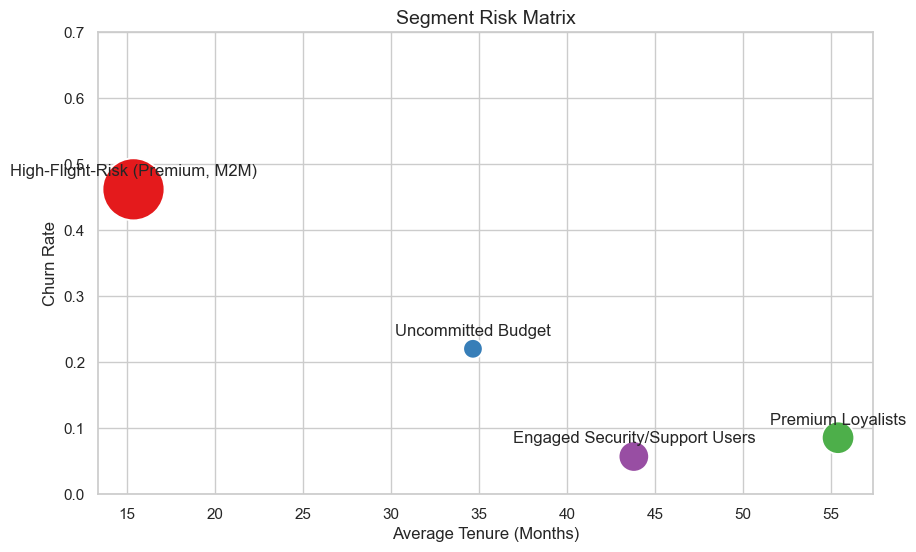

In [9]:
# Segment Risk Matrix (Tenure vs Churn Rate)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=ml_summary, x='Avg_Tenure', y='Churn_Rate', size='Customers', sizes=(200, 2000), hue='ml_segment', palette='Set1', legend=False)
for i in range(len(ml_summary)):
    plt.text(ml_summary['Avg_Tenure'].iloc[i], ml_summary['Churn_Rate'].iloc[i] + 0.02, ml_summary['ml_segment'].iloc[i], ha='center')
plt.title('Segment Risk Matrix')
plt.ylabel('Churn Rate')
plt.xlabel('Average Tenure (Months)')
plt.ylim(0, 0.7)
plt.show()

In [10]:
# Add Interpretation Column
ml_summary['Risk'] = ml_summary['Churn_Rate'].apply(lambda x: 'High' if x > 0.4 else ('Medium' if x > 0.2 else 'Low'))
ml_summary['Business Interpretation'] = [
    'Premium, month-to-month users with high churn risk. Need immediate intervention.',
    'New, low-cost users. High churn but low revenue impact.',
    'Long-term engaged users with support add-ons. Very stable.',
    'High value, highly loyal core customer base.'
]
ml_summary.to_csv('../data/processed/segmentation_summary.csv', index=False)
ml_summary

,ml_segment,Customers,Avg_Tenure,Avg_Monthly_Charges,Pct_MonthToMonth,Pct_TechSupport,Churn_Rate,% of Base,Risk,Business Interpretation
1,"High-Flight-Risk (Premium, M2M)",3083,15.353876,64.091486,0.998378,0.127149,0.461888,43.8,High,"Premium, month-to-month users with high churn ..."
3,Uncommitted Budget,1085,34.658065,75.131244,0.626728,0.152074,0.220276,15.4,Medium,"New, low-cost users. High churn but low revenu..."
2,Premium Loyalists,1473,55.419552,84.275221,0.077393,1.000000,0.085540,20.9,Low,Long-term engaged users with support add-ons. ...
0,Engaged Security/Support Users,1402,43.806705,37.708809,0.002140,0.009986,0.057061,19.9,Low,"High value, highly loyal core customer base."
